# Building block — ABX discrimination — configured by one file

> **Building block.** A minimal, copy-pasteable block (config explanation +
> run + save) and nothing else. Paste it together with other blocks — e.g.
> `building_block_consent.ipynb` to get a `participant_id` — to assemble your
> own experiment notebook.


This notebook runs a **classic ABX** discrimination test and saves the answers.
On each trial the participant hears three intervals — **A**, **B** and **X** —
where **X is a copy of A or B** (chosen at random). They decide whether X matches
A or B. ABX measures how reliably two stimuli can be told apart (chance = 50%).

Like the other whispy experiments it is **config-driven**: the whole thing is
described in [`configs/abx.yml`](../configs/abx.yml); only the shared look comes
from [`configs/design.yml`](../configs/design.yml). You should not need to edit
any Python below.

That one file is read by three consumers:

| block in the YAML | used by | configures |
|---|---|---|
| `SoundDevice:` | the audio handler | which WAV plays for each stimulus id |
| `test:` / `ui:` | the ABX window | A/B shuffling, window size, wording |
| `trial:` / `pairs:` / `experiment:` | this notebook | the prompt, the pairs to compare, and how many trials |

If you haven't installed the project yet, run this from the repo root:
`pip install -e .`

In [1]:
import whispy
import pandas as pd
from pathlib import Path
from whispy.interfaces import SoundDevice
from whispy.ui import ABX
from whispy.utils import read_config

config_path = Path('..') / 'configs' / 'abx.yml'   # <- the one file you edit
stimuli_dir = Path('demo_stimuli/abx')                  # <- folder with your WAVs

cfg = read_config(config_path)
handler = SoundDevice(config_path, stimuli_dir, loop=False)   # reads SoundDevice:
print('available stimulus ids:', list(handler.stimuli.keys()))

available stimulus ids: ['easy_a', 'easy_b', 'hard_a', 'hard_b']


## See your ABX experiment at a glance

Open [`configs/abx.yml`](../configs/abx.yml) to edit every setting (it has inline
comments). The cell below prints the current values and the pairs to be tested,
so you can review the design without leaving the notebook.

In [2]:
print('test      :', cfg['test'])
print('ui        :', cfg['ui'])
print('trial     :', cfg['trial'])
print('experiment:', cfg['experiment'])
print()
print('pairs (each is one A/B comparison):')
for i, p in enumerate(cfg['pairs'], start=1):
    print(f"  {i}. {p.get('name', '')}:  A={p['a']}   B={p['b']}")

test      : {'shuffle_ab': True}
ui        : {'content_area_size': [60, 80], 'listen_label': 'Listen:', 'answer_label': 'Your answer - X is the same as:', 'submit_hint': 'Play A, B and X (keys A/B/X), choose with ←/→, then press Enter to submit. \n You can also click the buttons with the mouse.', 'submit_button_text': 'Submit choice', 'show_progress': True, 'progress_text': 'Trial {current} of {total}'}
trial     : {'task': 'Is **X** the same as **A** or **B**?', 'block_name': 'ABX'}
experiment: {'repetitions': 6, 'shuffle_trials': True, 'seed': 0}

pairs (each is one A/B comparison):
  1. easy (clearly different):  A=easy_a   B=easy_b
  2. hard (subtle):  A=hard_a   B=hard_b


## Using your own stimuli

The WAVs in `examples/demo_stimuli/abx/` are **only a demo** (run
`python examples/demo_stimuli/abx/generate_abx_stimuli.py` to regenerate them). For a
real experiment you swap in your own files — you only touch the config and
`stimuli_dir`, never the Python.

1. **Point `stimuli_dir`** (in the setup cell) at the folder holding your WAVs.
2. **Map ids to files** under `SoundDevice:` in
   [`configs/abx.yml`](../configs/abx.yml), then list the comparisons under
   `pairs:` using those ids:
   ```yaml
   SoundDevice:
     ref:  { file: reference.wav }
     proc: { file: processed.wav }
   pairs:
     - { a: ref, b: proc, name: my comparison }
   ```

**Safety constraints** (checked when the handler loads in the setup cell — a
violation raises a `ValueError`):

- **No clipping** — every sample must satisfy `|amplitude| < 1` (normalise with headroom, e.g. ~0.7).
- **One sampling rate** — every file must share the same sampling rate.
- **All ids must exist** — every id used under `pairs:` must be defined under `SoundDevice:`.

Run the next cell to **pre-flight-check your files before testing a
participant**. After changing the config or `stimuli_dir`, re-run the setup cell.

In [3]:
import numpy as np
import pyfar as pf

def check_stimuli(config_path, stimuli_dir):
    """Validate the stimulus set: existence, clipping, one sampling rate, and
    that every id used by a pair is defined."""
    cfg = read_config(config_path)
    sound = cfg.get('SoundDevice', {})
    pairs = cfg.get('pairs', [])
    folder = Path(stimuli_dir)

    problems, rates = [], {}
    print(f'Checking {len(sound)} stimuli in {folder.resolve()}\n')
    for sid, spec in sound.items():
        path = folder / spec['file']
        if not path.exists():
            problems.append(f"id {sid!r}: file not found -> {path}")
            print(f"  {str(sid):>8}  MISSING   {spec['file']}")
            continue
        sig = pf.io.read_audio(path)
        peak = float(np.max(np.abs(sig.time)))
        rates[sid] = sig.sampling_rate
        flag = '  <-- CLIPPING' if peak >= 1 else ''
        print(f"  {str(sid):>8}  {sig.sampling_rate} Hz  peak={peak:.3f}  {spec['file']}{flag}")
        if peak >= 1:
            problems.append(f"id {sid!r}: clips (peak={peak:.3f} >= 1)")

    for pair in pairs:
        for role in ('a', 'b'):
            rid = pair.get(role)
            if rid not in sound:
                problems.append(f"pair {pair.get('name', pair)!r} uses id {rid!r}, not defined under SoundDevice:")

    if len(set(rates.values())) > 1:
        problems.append(f"mixed sampling rates: {sorted(set(rates.values()))} (all must match)")

    print()
    if problems:
        print('NOT ready - fix these before running:')
        for prob in problems:
            print('  -', prob)
    else:
        print('All good: files exist, no clipping, one sampling rate, all pair ids defined.')
    return not problems

check_stimuli(config_path, stimuli_dir)

Checking 4 stimuli in D:\Uni\Sem IV\P&A\Whispy\whispy\examples\demo_stimuli\abx

    easy_a  44100 Hz  peak=0.700  easy_a.wav
    easy_b  44100 Hz  peak=0.700  easy_b.wav
    hard_a  44100 Hz  peak=0.700  hard_a.wav


    hard_b  44100 Hz  peak=0.700  hard_b.wav

All good: files exist, no clipping, one sampling rate, all pair ids defined.


True

## Build the trial list

Each pair is presented `experiment.repetitions` times. For every trial we also
decide here (with the config's `seed`, so it is reproducible) whether **X** is a
copy of A or B. The ABX window additionally randomizes which stimulus is shown as
A vs B when `test.shuffle_ab` is on.

In [4]:
import random

exp = cfg['experiment']
trial = cfg['trial']
rng = random.Random(exp.get('seed', 0))

trials = []
for pair in cfg['pairs']:
    for _ in range(int(exp.get('repetitions', 1))):
        t = dict(pair)
        t['x'] = rng.choice([pair['a'], pair['b']])   # which stimulus X copies
        trials.append(t)
if exp.get('shuffle_trials', True):
    rng.shuffle(trials)

def build_screen(pair, trial_index):
    return {
        'a': pair['a'], 'b': pair['b'], 'x': pair['x'],
        'task': trial['task'],
        'block': 0, 'section': 0,
        'trial_id': trial_index,
        'block_name': trial.get('block_name', 'ABX'),
        'section_name': pair.get('name', 'pair'),
        # drives the "Trial X of Y" progress bar (ui.show_progress)
        'progress': {'current': trial_index, 'total': len(trials)},
    }

print(f"{len(trials)} trials ({len(cfg['pairs'])} pairs x {exp.get('repetitions')} repetitions)")

12 trials (2 pairs x 6 repetitions)


## Run it

The loop below presents every trial, reusing **one window** for the whole
experiment (the first trial opens it; later trials swap their content into the
same window via `parent=host`, so it stays fullscreen with no reload). The window
is closed in a `finally` block when the run finishes.

In each trial: press **A**, **B**, **X** (or click) to hear each interval, choose
the match with **←/→** (or click A/B), then press **Enter** to submit.

In [5]:
host = None

def run_trial(screen):
    global host
    abx = ABX(screen=screen, stimuli_handler=handler,
              abx_config=config_path, blocking=True, parent=host)
    if host is None:
        host = abx            # first trial owns the shared window
    return abx.get_results()

rows = []
try:
    for i, pair in enumerate(trials, start=1):
        rows.append(run_trial(build_screen(pair, i)))
finally:
    if host is not None:
        host.close()

results = pd.concat(rows, ignore_index=True)
results

,block,section,trial_id,block_name,section_name,a,b,x,correct,selected,correct_bool,rt
0,0,0,1,ABX,easy (clearly different),easy_b,easy_a,easy_b,A,A,True,21.340872
1,0,0,2,ABX,hard (subtle),hard_a,hard_b,hard_b,B,B,True,6.950464
2,0,0,3,ABX,hard (subtle),hard_a,hard_b,hard_a,A,A,True,4.287621
3,0,0,4,ABX,hard (subtle),hard_b,hard_a,hard_b,A,B,False,5.168751
4,0,0,5,ABX,easy (clearly different),easy_b,easy_a,easy_b,A,A,True,4.968097
5,0,0,6,ABX,easy (clearly different),easy_a,easy_b,easy_b,B,A,False,9.726824
6,0,0,7,ABX,hard (subtle),hard_a,hard_b,hard_b,B,B,True,6.499304
7,0,0,8,ABX,hard (subtle),hard_b,hard_a,hard_b,A,A,True,4.241954
8,0,0,9,ABX,easy (clearly different),easy_b,easy_a,easy_b,A,B,False,4.055561
9,0,0,10,ABX,hard (subtle),hard_b,hard_a,hard_a,B,A,False,4.025895


## Results & percent correct

`results` has one row per trial (`a`, `b`, `x`, `correct`, `selected`,
`correct_bool`, `rt`, ...). ABX performance is summarized as **percent correct**,
overall and per pair. Chance is **50%**; well above that means the pair is
discriminable.

In [6]:
overall = results['correct_bool'].mean()
print(f'overall percent correct: {overall * 100:.1f}%   (n={len(results)}, chance=50%)')
print()
per_pair = (results.groupby('section_name')['correct_bool']
            .agg(percent_correct=lambda s: round(s.mean() * 100, 1), n='count'))
print('per pair:')
print(per_pair.to_string())

overall percent correct: 58.3%   (n=12, chance=50%)

per pair:
                          percent_correct  n
section_name                                
easy (clearly different)             50.0  6
hard (subtle)                        66.7  6


## Save the results

Save the results to a CSV in a `results/` folder (created next to this notebook).
The file name always carries a **timestamp**. If a `participant_id` is in scope
(set by a consent block earlier in the notebook) it is included
(`<name>_<id>_<timestamp>.csv`); otherwise an iterating fallback number is used
(`<name>_<NNN>_<timestamp>.csv`). Existing files are never overwritten.

In [7]:
from whispy.utils import save_results

# `participant_id` is picked up automatically if a consent block earlier in this
# notebook set it; otherwise it is None and the file name uses an iterating
# fallback number.
participant_id = globals().get('participant_id')
results_path = save_results(results, 'abx', participant_id=participant_id)
print('saved results to', results_path.resolve())

saved results to D:\Uni\Sem IV\P&A\Whispy\whispy\examples\results\abx_0001_20260710_031409.csv


## Plot the results

Plot up to three plots. A plot with the accuracy by section can be created. It will also show the 95% confidence interval.
A boxplot of the reaction times by correctness can be created as well and lastly, the reaction time and correctness over the trials can be illustrated by graphs.

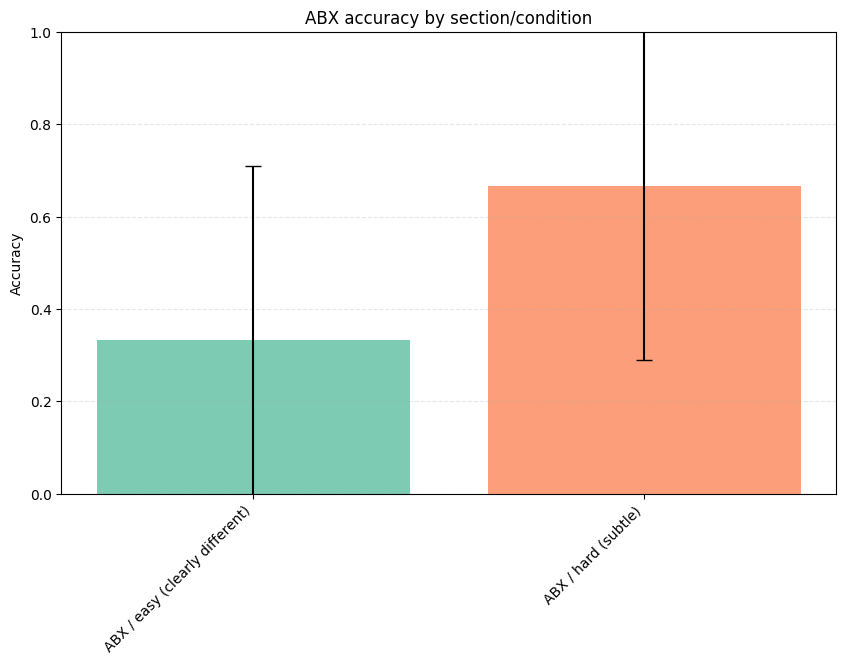

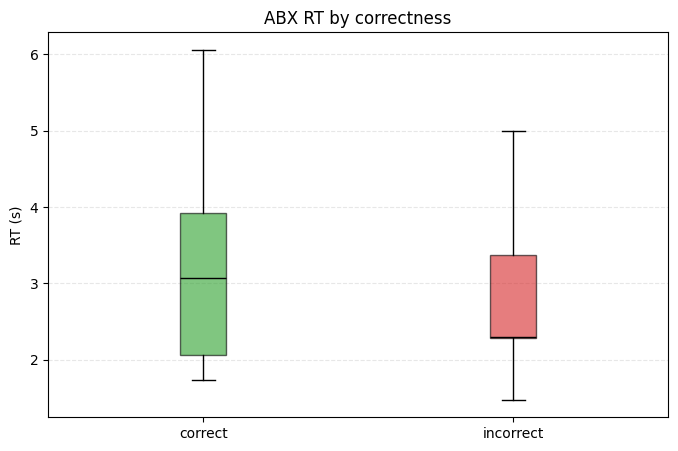

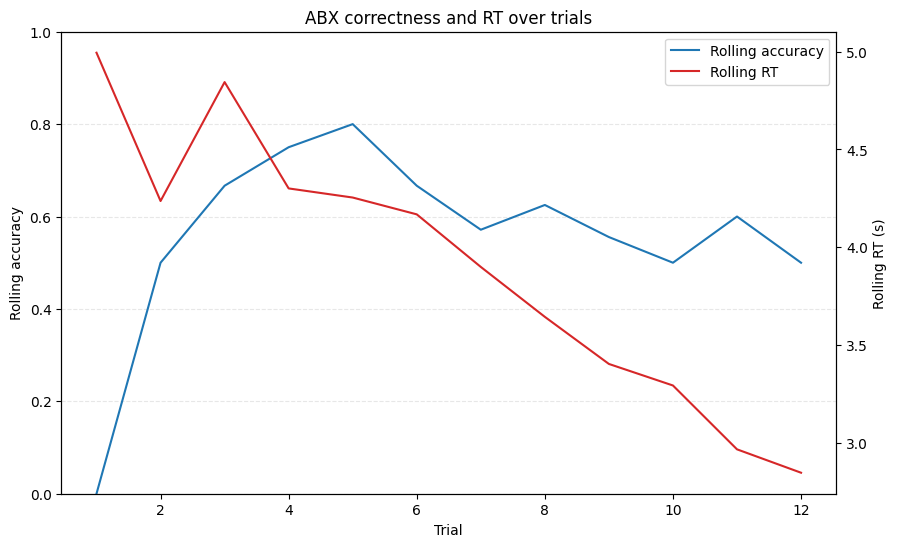

In [ ]:
from whispy.utils import Plotting as plt

plt().plot_abx_accuracy_by_section(results)
plt().plot_abx_rt_boxplot(results)
plt().plot_abx_correctness_rt_over_trials(results)